In [1]:
!pip install mesa[rec]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.8/108.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.5/264.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.9 MB/s eta 0:00:00


In [2]:
!pip install seaborn


In [8]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [82]:

import random
from mesa.datacollection import DataCollector
import matplotlib.pyplot as plt



class NewsReactiveAgent(mesa.Agent):
    def __init__(self, model, reaction_type="normal", window_size=5, discount_factor=0.9):
        super().__init__(model)

        # Tepki katsayıları (asimetrik)
        if reaction_type == "low":
            self.beta_pos = 0.8
            self.beta_neg = 1.0
        elif reaction_type == "normal":
            self.beta_pos = 1.0
            self.beta_neg = 1.2
        elif reaction_type == "high":
            self.beta_pos = 1.2
            self.beta_neg = 1.5

        self.reaction_type = reaction_type
        self.window_size = window_size
        self.discount_factor = discount_factor
        self.news_window = []

    def yap(self):
        news = self.model.generate_news()

        if news < 0:
            reaction = self.beta_neg * news
        else:
            reaction = self.beta_pos * news

        self.news_window.append(reaction)
        if len(self.news_window) > self.window_size:
            self.news_window.pop(0)

    def evaluate_sentiment(self):
        n = len(self.news_window)
        weights = [self.discount_factor ** i for i in reversed(range(n))]

        weighted_sum = sum(w * r for w, r in zip(weights, self.news_window))
        total_weight = sum(weights)

        return weighted_sum / total_weight if total_weight != 0 else 0



class NewsMarketModel(mesa.Model):
    def __init__(self, N):
        super().__init__()

        self.num_agents = N


        # Haber dağılımı
        self.news_values = [-2, -1, 0, 1, 2]
        self.news_probs = [0.05, 0.20, 0.50, 0.20, 0.05]

        # Ajanları oluştur
        for i in range(self.num_agents):
            if i % 3 == 0:
                reaction = "low"
            elif i % 3 == 1:
                reaction = "normal"
            else:
                reaction = "high"
            agent = NewsReactiveAgent(self, reaction_type=reaction)
            self.agents.add(agent)

        # DataCollector'ı güncelle

        self.datacollector = mesa.DataCollector(
            agent_reporters={
                "ReactionType": lambda a: a.reaction_type,
                "BetaPos": lambda a: a.beta_pos,
                "BetaNeg": lambda a: a.beta_neg,
                "Sentiment": lambda a: a.evaluate_sentiment(),
                "NewsWindowSize": lambda a: len(a.news_window),
                "LastNewsImpact": lambda a: a.news_window[-1] if a.news_window else 0
            },
            model_reporters={
                "NewsValues": lambda m: m.news_values,
                "NewsProbs": lambda m: m.news_probs
            }

        )





    def step(self):
        self.agents.do("yap")
        self.datacollector.collect(self)  # Veriyi topla


    def generate_news(self):
        return np.random.choice(self.news_values, p=self.news_probs)





In [83]:
# Modeli oluştur ve çalıştır
model = NewsMarketModel(N=100)
for i in range(10):  # 10 adım çalıştır
    model.step()

# Toplanan verileri al
agent_data = model.datacollector.get_agent_vars_dataframe()
model_data = model.datacollector.get_model_vars_dataframe()

# Verileri görüntüle
print("++++++++++++++Agent Verileri+++++++++++++")
print(agent_data)

print("\n++++++++++++Model Verileri+++++++++++++")
print(model_data)



++++++++++++++Agent Verileri+++++++++++++
             ReactionType  BetaPos  BetaNeg  Sentiment  NewsWindowSize  \
Step AgentID                                                             
1    1                low      0.8      1.0   0.000000               1   
     2             normal      1.0      1.2  -1.200000               1   
     3               high      1.2      1.5   0.000000               1   
     4                low      0.8      1.0   0.000000               1   
     5             normal      1.0      1.2   0.000000               1   
...                   ...      ...      ...        ...             ...   
10   96              high      1.2      1.5   0.293033               5   
     97               low      0.8      1.0   0.035140               5   
     98            normal      1.0      1.2   0.178262               5   
     99              high      1.2      1.5  -0.036629               5   
     100              low      0.8      1.0   0.750399               5

In [84]:
model = NewsMarketModel(10)

for step in range(10):
    print(f"=== Step {step} ===")
    model.step()
    for agent in model.agents:
        sentiment = agent.evaluate_sentiment()
        print(f"Ajan {agent.unique_id} - ({agent.reaction_type}) - değerlendirme (weights): {sentiment:.2f}")


=== Step 0 ===
Ajan 1 - (low) - değerlendirme (weights): 0.00
Ajan 2 - (normal) - değerlendirme (weights): 1.00
Ajan 3 - (high) - değerlendirme (weights): 1.20
Ajan 4 - (low) - değerlendirme (weights): 0.00
Ajan 5 - (normal) - değerlendirme (weights): 0.00
Ajan 6 - (high) - değerlendirme (weights): 0.00
Ajan 7 - (low) - değerlendirme (weights): -1.00
Ajan 8 - (normal) - değerlendirme (weights): 0.00
Ajan 9 - (high) - değerlendirme (weights): 1.20
Ajan 10 - (low) - değerlendirme (weights): 0.00
=== Step 1 ===
Ajan 1 - (low) - değerlendirme (weights): 0.00
Ajan 2 - (normal) - değerlendirme (weights): 0.47
Ajan 3 - (high) - değerlendirme (weights): 1.20
Ajan 4 - (low) - değerlendirme (weights): 0.00
Ajan 5 - (normal) - değerlendirme (weights): -0.63
Ajan 6 - (high) - değerlendirme (weights): -0.79
Ajan 7 - (low) - değerlendirme (weights): -1.00
Ajan 8 - (normal) - değerlendirme (weights): 0.53
Ajan 9 - (high) - değerlendirme (weights): 0.57
Ajan 10 - (low) - değerlendirme (weights): 0.00


In [74]:
# Ajan verisini pandas DataFrame olarak al
agent_df = model.datacollector.get_agent_vars_dataframe()

# Check data types and convert if necessary
# For example, if "Nakit" column is not numeric, convert it to numeric
agent_df["reaction"] = pd.to_numeric(agent_df["reaction"])

gr = sns.lineplot(data=agent_df, x="Step", y="reaction", hue="AgentID") # Specify x and y
gr.set(title="Step", ylabel="reaction");

KeyError: 'reaction'

In [4]:
import random
from mesa.datacollection import DataCollector
import matplotlib.pyplot as plt



class MoneyAgent(mesa.Agent):
    """An agent with fixed initial wealth."""

    def __init__(self, model, trader_type):
        # Pass the parameters to the parent class.
        super().__init__(model)

        self.trader_type = trader_type  # "technical", "fundamental", "noise"
        self.cash = 1000  # Başlangıç nakit miktarı
        self.shares = 10  # Başlangıç hisse sayısı
        self.history_window = random.randint(14, 200)  # Geçmiş veri penceresi

        self.al_sayisi = 0
        self.sat_sayisi = 0

#

    def step(self):
        """ Ajanın her adımda yapacağı işlem """

        market_trend = self.analyze_market()

        if self.trader_type == "technical":
            self.technical_trading(market_trend)
            print(f"ID: {self.unique_id}")
            print(f"Trader Type: {self.trader_type}")
            print(f"Cash: {self.cash}")
            print(f"Shares: {self.shares}")


        elif self.trader_type == "fundamental":
            self.fundamental_trading(market_trend)
            print(f"ID: {self.unique_id}")
            print(f"Trader Type: {self.trader_type}")
            print(f"Cash: {self.cash}")
            print(f"Shares: {self.shares}")


        elif self.trader_type == "noise":
            self.noise_trading()
            print(f"ID: {self.unique_id}")
            print(f"Trader Type: {self.trader_type}")
            print(f"Cash: {self.cash}")
            print(f"Shares: {self.shares}")

        #print(f"döngü: {self.sayac}") #self.sayac is not defined

    def analyze_market(self):
        """ Piyasanın boğa, ayı veya aralık piyasası olduğunu belirle """
        if len(self.model.price_history) < self.history_window:
            return "unknown"  # Yeterli veri yoksa belirleme yapma

        recent_prices = self.model.price_history[-self.history_window:]
        price_changes = np.diff(recent_prices)

        if np.all(price_changes > 0):
            return "bull"  # Boğa piyasası
        elif np.all(price_changes < 0):
            return "bear"  # Ayı piyasası
        else:
            return "range"  # Aralık piyasası

    def technical_trading(self, market_trend):
        """ Teknik analiz bazlı alım-satım """
        if market_trend == "bull":
            self.buy_stock()
            self.al_sayisi += 1
            print(f"Alım Sayısı: {self.al_sayisi}")
        elif market_trend == "bear":
            self.sell_stock()
            self.sat_sayisi += 1
            print(f"Satım Sayısı: {self.sat_sayisi}")
        else:
            if random.random() < 0.5:
                self.buy_stock()
                self.al_sayisi += 1
                print(f"Alım Sayısı: {self.al_sayisi}")
            else:
                self.sell_stock()
                self.sat_sayisi += 1
                print(f"Satım Sayısı: {self.sat_sayisi}")

    def fundamental_trading(self, market_trend):
        """ Temel analiz bazlı alım-satım """
        if market_trend == "bull":
            self.buy_stock()
            self.al_sayisi += 1
            print(f"Alım Sayısı: {self.al_sayisi}")
        elif market_trend == "bear":
            self.sell_stock()
            self.sat_sayisi += 1
            print(f"Satım Sayısı: {self.sat_sayisi}")
        else:
            if random.random() < 0.6:
                self.buy_stock()
                self.al_sayisi += 1
                print(f"Alım Sayısı: {self.al_sayisi}")
            else:
                self.sell_stock()
                self.sat_sayisi += 1
                print(f"Satım Sayısı: {self.sat_sayisi}")



    def noise_trading(self):
        """ Gürültü yatırımcılarının rastgele işlemleri """
        if random.random() < 0.5:
            self.buy_stock()
            self.al_sayisi += 1
            print(f"Alım Sayısı: {self.al_sayisi}")
        else:
            self.sell_stock()
            self.sat_sayisi += 1
            print(f"Satım Sayısı: {self.sat_sayisi}")

    def buy_stock(self):
        """ Hisse senedi satın alma """
        if self.cash >= self.model.stock_price:
            self.cash -= self.model.stock_price
            self.shares += 1

    def sell_stock(self):
        """ Hisse senedi satma """
        if self.shares > 0:
            self.cash += self.model.stock_price
            self.shares -= 1


class MoneyModel(mesa.Model):
    """A model with some number of agents."""

    def __init__(self, n, tech_ratio=0.4, fund_ratio=0.4, noise_ratio=0.2, seed=None):
        super().__init__(seed=seed)
        self.num_agents = n
        #self.stock_price = 100  # Başlangıç hisse fiyatı
        self.sayac = 0

        # 300 günlük geçmiş fiyat serisi oluştur (rastgele yürüyüş)
        self.price_history = [100]  # İlk değer
        for _ in range(299):
            self.price_history.append(self.price_history[-1] + random.uniform(-1, 1))

        self.stock_price = self.price_history[-1]  # Son değeri başlangıç fiyatı olarak al


        # Ajan sayılarını belirleme
        num_technical = int(self.num_agents * tech_ratio)
        num_fundamental = int(self.num_agents * fund_ratio)
        num_noise = self.num_agents - (num_technical + num_fundamental)  # Geriye kalanlar noise olur

        # Ajanları oluştur ve modele ekle
        for i in range(num_technical):
            agent = MoneyAgent(self, "technical")
            self.agents.add(agent)
        for i in range(num_fundamental):
            agent = MoneyAgent(self, "fundamental")
            self.agents.add(agent)
        for i in range(num_noise):
            agent = MoneyAgent(self, "noise")
            self.agents.add(agent)


        # DataCollector'ı ayarla
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Price": lambda m: m.stock_price,  # Güncel fiyat
                "Price_History": lambda m: m.price_history.copy()  # Tüm fiyat geçmişi
            },
            agent_reporters={"Nakit": "cash"}  # Ajan seviyesinde veri

        )

    def step(self):
        """ Modelin her adımda çalıştırılması """
        self.agents.do("step")  # Tüm ajanları çalıştır
        self.update_stock_price()  # Piyasa fiyatını güncelle
        self.sayac += 1
        print(f"+++++++++++++++++++++++++++++Sayac: {self.sayac}")
        self.datacollector.collect(self)  # Veriyi topla


    def update_stock_price(self):
        """ Basit bir fiyat güncelleme mekaniği """
        self.stock_price += random.uniform(-1, 1)  # Şimdilik rastgele değişim
        self.price_history.append(self.stock_price)



In [5]:
model = MoneyModel(5)
for i in range(40):
  model.step()
  #print(model.stock_price)

Alım Sayısı: 1
ID: 1
Trader Type: technical
Cash: 918.0428626862306
Shares: 11
Alım Sayısı: 1
ID: 2
Trader Type: technical
Cash: 918.0428626862306
Shares: 11
Alım Sayısı: 1
ID: 3
Trader Type: fundamental
Cash: 918.0428626862306
Shares: 11
Alım Sayısı: 1
ID: 4
Trader Type: fundamental
Cash: 918.0428626862306
Shares: 11
Satım Sayısı: 1
ID: 5
Trader Type: noise
Cash: 1081.9571373137694
Shares: 9
+++++++++++++++++++++++++++++Sayac: 1
Satım Sayısı: 1
ID: 1
Trader Type: technical
Cash: 1000.9447842421108
Shares: 10
Satım Sayısı: 1
ID: 2
Trader Type: technical
Cash: 1000.9447842421108
Shares: 10
Alım Sayısı: 2
ID: 3
Trader Type: fundamental
Cash: 835.1409411303504
Shares: 12
Alım Sayısı: 2
ID: 4
Trader Type: fundamental
Cash: 835.1409411303504
Shares: 12
Alım Sayısı: 1
ID: 5
Trader Type: noise
Cash: 999.0552157578892
Shares: 10
+++++++++++++++++++++++++++++Sayac: 2
Satım Sayısı: 2
ID: 1
Trader Type: technical
Cash: 1083.4536436546725
Shares: 9
Alım Sayısı: 2
ID: 2
Trader Type: technical
Cash:

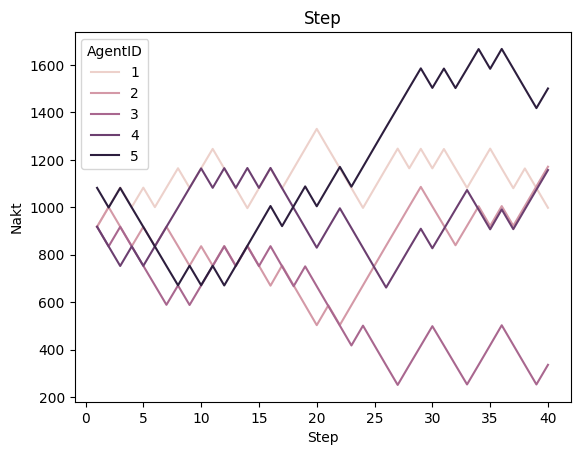

In [6]:
# Ajan verisini pandas DataFrame olarak al
agent_df = model.datacollector.get_agent_vars_dataframe()

# Check data types and convert if necessary
# For example, if "Nakit" column is not numeric, convert it to numeric
agent_df["Nakit"] = pd.to_numeric(agent_df["Nakit"])

gr = sns.lineplot(data=agent_df, x="Step", y="Nakit", hue="AgentID") # Specify x and y
gr.set(title="Step", ylabel="Nakt");

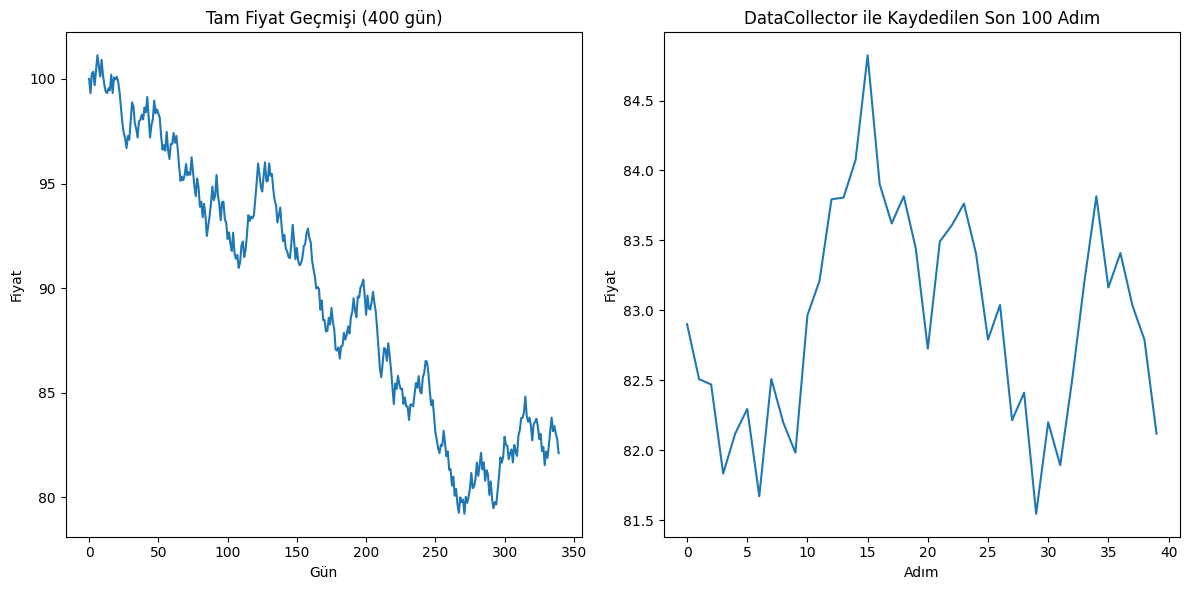

In [7]:
# Extract MoneyModel data in a Pandas dataframe
model_data = model.datacollector.get_model_vars_dataframe()

# Grafik çiz
plt.figure(figsize=(12, 6))

# 1. Tüm price_history'nin grafiği
plt.subplot(1, 2, 1)
all_prices = model.price_history
plt.plot(all_prices, label='Tüm Fiyat Geçmişi')
plt.title("Tam Fiyat Geçmişi (400 gün)")
plt.xlabel("Gün")
plt.ylabel("Fiyat")

# 2. DataCollector ile kaydedilen son 100 adımın grafiği
plt.subplot(1, 2, 2)
last_100_prices = model_data["Price"].tail(100)
last_100_prices.plot(label='Son 100 Adım')
plt.title("DataCollector ile Kaydedilen Son 100 Adım")
plt.xlabel("Adım")
plt.ylabel("Fiyat")

plt.tight_layout()
plt.show()